In [ ]:
import pandas as pd 
import numpy as np 
from pathlib import Path 
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_auc_score , classification_report , confusion_matrix 

OUTPUT_DIR = Path(r"C:\f1 new\data") 
df = pd.read_parquet(OUTPUT_DIR / "f1_gold.parquet") 
print(f"Gold: {len(df):,} rows") 
print(f"Features: {df.shape[1]:,} columns") 

Gold: 94,711 rows
Features: 20 columns


In [ ]:
feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct', 'DegradationRate',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
] 

x = df[feature_cols] 
y = df['WillPitNextLap'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2) 
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1) 

model.fit(x_train, y_train) 
model.predict(x_test) 
print(f"ROC AUC Score: {roc_auc_score(y_test, model.predict(x_test)):.4f}" ) 
print(classification_report(y_test, model.predict(x_test).round())) 

ROC AUC Score: 0.5038
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18416
           1       1.00      0.01      0.02       527

    accuracy                           0.97     18943
   macro avg       0.99      0.50      0.50     18943
weighted avg       0.97      0.97      0.96     18943



In [ ]:
neg_support = (y_train == 0).sum()
pos_support = (y_train == 1).sum() 
scale_pos_weight= neg_support / pos_support 

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos_weight) 

model.fit(x_train, y_train) 
model.predict(x_test) 
print(f"ROC AUC Score: {roc_auc_score(y_test, model.predict(x_test)):.4f}" ) 
print(classification_report(y_test, model.predict(x_test).round()))

ROC AUC Score: 0.7756
              precision    recall  f1-score   support

           0       0.99      0.77      0.86     18416
           1       0.09      0.79      0.16       527

    accuracy                           0.77     18943
   macro avg       0.54      0.78      0.51     18943
weighted avg       0.97      0.77      0.84     18943



In [ ]:
scale_weight_balanced = np.sqrt(neg_support / pos_support) 

model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1,
    scale_pos_weight=scale_weight_balanced, 
    max_delta_step=1,
    random_state=42
) 

model.fit(x_train, y_train) 
model.predict(x_test) 
print(f"ROC AUC Score: {roc_auc_score(y_test, model.predict(x_test)):.4f}" ) 
print(classification_report(y_test, model.predict(x_test).round()))

ROC AUC Score: 0.5595
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     18416
           1       0.22      0.13      0.16       527

    accuracy                           0.96     18943
   macro avg       0.60      0.56      0.57     18943
weighted avg       0.95      0.96      0.96     18943



In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , stratify = y , random_state=42) 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum() 

model = XGBClassifier(
    n_estimators=300,
    max_depth=6 , 
    learning_rate=0.05 , 
    scale_pos_weight= np.sqrt(neg / pos) , 
    random_state=42
) 
model.fit(x_train, y_train) 

y_proba = model.predict_proba(x_test)[:,1] 
y_pred = model.predict(x_test) 

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}" ) 
print(classification_report(y_test, y_pred)) 

ROC AUC Score: 0.8711
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18407
           1       0.29      0.26      0.28       536

    accuracy                           0.96     18943
   macro avg       0.63      0.62      0.63     18943
weighted avg       0.96      0.96      0.96     18943



In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds: 
    y_pred_t = (y_proba >= t).astype(int) 
    print(f"\nThreshold: {t:.2f}") 
    report = classification_report(y_test, y_pred_t , output_dict=True) 

    print(f"Threshold = {t} | "
        f"Precision:{report['1']['precision']:.2f} |" 
        f"Recall:{report['1']['recall']:.2f} | "
        f"F1-Score:{report['1']['f1-score']:.2f}")


Threshold: 0.30
Threshold = 0.3 | Precision:0.16 |Recall:0.59 | F1-Score:0.25

Threshold: 0.40
Threshold = 0.4 | Precision:0.21 |Recall:0.40 | F1-Score:0.27

Threshold: 0.50
Threshold = 0.5 | Precision:0.29 |Recall:0.26 | F1-Score:0.28

Threshold: 0.60
Threshold = 0.6 | Precision:0.36 |Recall:0.15 | F1-Score:0.21


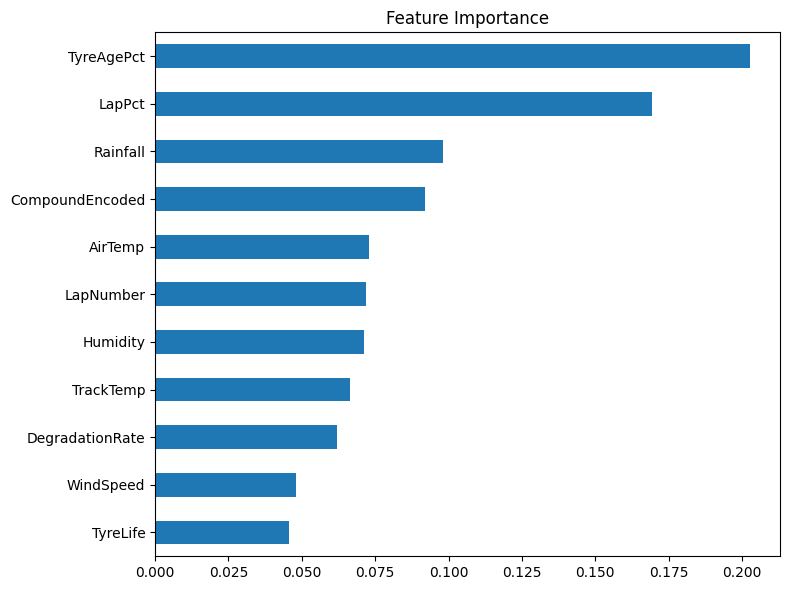

In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , stratify = y , random_state=42) 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum() 

model = XGBClassifier(
    n_estimators=300,
    max_depth=6 , 
    learning_rate=0.05 , 
    scale_pos_weight= 10 , 
    random_state=42
) 
model.fit(x_train, y_train) 

y_proba = model.predict_proba(x_test)[:,1] 
y_pred = model.predict(x_test) 

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}" ) 
print(classification_report(y_test, y_pred)) 

ROC AUC Score: 0.8681
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18407
           1       0.20      0.43      0.27       536

    accuracy                           0.94     18943
   macro avg       0.59      0.69      0.62     18943
weighted avg       0.96      0.94      0.95     18943



In [ ]:
df_o = df.copy()

In [ ]:
df = pd.read_parquet(OUTPUT_DIR / "f1_gold.parquet") 


In [ ]:
from sklearn.metrics import f1_score , recall_score , accuracy_score , precision_score 
feature = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

x = df[feature]
y = df['WillPitNextLap']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg/pos,
    random_state=42
)

model.fit(x_train, y_train)

y_proba = model.predict_proba(x_test)[:, 1]
y_pred  = model.predict(x_test)

print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

ROC AUC  : 0.8692
F1       : 0.1923
Recall   : 0.7481
Precision: 0.1103
Accuracy : 0.8222


In [ ]:
from sklearn.metrics import f1_score , recall_score , accuracy_score , precision_score 
feature = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

x = df[feature]
y = df['WillPitNextLap']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=5,
    random_state=42
)

model.fit(x_train, y_train)

y_proba = model.predict_proba(x_test)[:, 1]
y_pred  = model.predict(x_test)

print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

ROC AUC  : 0.8741
F1       : 0.2576
Recall   : 0.2220
Precision: 0.3067
Accuracy : 0.9638


In [ ]:
from sklearn.metrics import f1_score , recall_score , accuracy_score , precision_score 
feature = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

x = df[feature]
y = df['WillPitNextLap']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=15,
    random_state=42
)

model.fit(x_train, y_train)

y_proba = model.predict_proba(x_test)[:, 1]
y_pred  = model.predict(x_test)

print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

ROC AUC  : 0.8725
F1       : 0.2496
Recall   : 0.5690
Precision: 0.1599
Accuracy : 0.9032


In [ ]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from imblearn.over_sampling import SMOTE 

smote = SMOTE(random_state = 42) 
x_train_sm , y_train_sm = smote.fit_resample(x_train , y_train) 

print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After : {pd.Series(y_train_sm).value_counts().to_dict()}")

Before: {0: 73625, 1: 2143}
After : {0: 73625, 1: 73625}


In [ ]:
from sklearn.metrics import f1_score , recall_score , accuracy_score , precision_score 
feature = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]
x = df[feature]
y = df['WillPitNextLap']
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
model.fit(x_train_sm, y_train_sm)
y_proba = model.predict_proba(x_test)[:, 1]
y_pred  = model.predict(x_test)
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}") 

ROC AUC  : 0.8576
F1       : 0.2367
Recall   : 0.4683
Precision: 0.1584
Accuracy : 0.9145


In [ ]:
df_gold = pd.read_parquet(OUTPUT_DIR / "f1_gold.parquet")

feature = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

x = df_gold[feature]
y = df_gold['WillPitNextLap']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg/pos,
    random_state=42
)

model.fit(x_train, y_train)

y_proba = model.predict_proba(x_test)[:, 1]
y_pred  = model.predict(x_test)

print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

ROC AUC  : 0.8757
F1       : 0.2043
Recall   : 0.7668
Precision: 0.1179
Accuracy : 0.8310


In [ ]:
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"Threshold={t} | "
        f"Recall={recall_score(y_test, y_pred_t):.2f} | "
        f"Precision={precision_score(y_test, y_pred_t):.2f} | "
        f"F1={f1_score(y_test, y_pred_t):.2f}")

Threshold=0.1 | Recall=0.95 | Precision=0.05 | F1=0.10
Threshold=0.15 | Recall=0.93 | Precision=0.06 | F1=0.11
Threshold=0.2 | Recall=0.92 | Precision=0.07 | F1=0.13
Threshold=0.25 | Recall=0.91 | Precision=0.08 | F1=0.14
Threshold=0.3 | Recall=0.89 | Precision=0.08 | F1=0.15


In [ ]:
results = [] 

for spw in [5,10,15]:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=spw,
        random_state=42
    )
    model.fit(x_train, y_train)
    y_proba = model.predict_proba(x_test)[:, 1]
    y_pred  = model.predict(x_test)
    
    results.append({
        'scale_pos_weight': spw,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred)
    }) 

print(pd.DataFrame(results).sort_values(by='f1', ascending=False))

   scale_pos_weight   roc_auc        f1    recall  precision  accuracy
1                10  0.883878  0.293792  0.445896   0.219065  0.939344
2                15  0.881092  0.267997  0.576493   0.174576  0.910891
0                 5  0.886535  0.260593  0.229478   0.301471  0.963153


In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42
)
model.fit(x_train, y_train)
y_proba = model.predict_proba(x_test)[:, 1]

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"t={t} | "
        f"Recall={recall_score(y_test, y_pred_t):.2f} | "
        f"Precision={precision_score(y_test, y_pred_t):.2f} | "
        f"F1={f1_score(y_test, y_pred_t):.2f}")

t=0.3 | Recall=0.74 | Precision=0.14 | F1=0.23
t=0.35 | Recall=0.66 | Precision=0.15 | F1=0.24
t=0.4 | Recall=0.59 | Precision=0.17 | F1=0.26
t=0.45 | Recall=0.51 | Precision=0.19 | F1=0.28
t=0.5 | Recall=0.45 | Precision=0.22 | F1=0.29


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6, 
    class_weight='balanced' ,
    random_state=42
)
model.fit(x_train, y_train)
y_proba = model.predict_proba(x_test)[:, 1]

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"t={t} | "
        f"Recall={recall_score(y_test, y_pred_t):.2f} | "
        f"Precision={precision_score(y_test, y_pred_t):.2f} | "
        f"F1={f1_score(y_test, y_pred_t):.2f}") 

t=0.3 | Recall=0.95 | Precision=0.05 | F1=0.10
t=0.35 | Recall=0.93 | Precision=0.06 | F1=0.11
t=0.4 | Recall=0.91 | Precision=0.06 | F1=0.12
t=0.45 | Recall=0.89 | Precision=0.07 | F1=0.13
t=0.5 | Recall=0.85 | Precision=0.07 | F1=0.13


In [ ]:
from sklearn.ensemble import VotingClassifier 
from lightgbm import LGBMClassifier 

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42
) 

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6, 
    class_weight='balanced' ,
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

ensemble = VotingClassifier(
    estimators = [('xgb', xgb), ('rf', rf), ('lgbm', lgbm)], 
    voting = 'soft'
) 

ensemble.fit(x_train , y_train) 
y_proba = ensemble.predict_proba(x_test)[:, 1] 

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:  
    y_pred_t = (y_proba >= t).astype(int) 
    print(f"t={t} | "
        f"Recall={recall_score(y_test, y_pred_t):.2f} | "
        f"Precision={precision_score(y_test, y_pred_t):.2f} | "
        f"F1={f1_score(y_test, y_pred_t):.2f}") 

[LightGBM] [Info] Number of positive: 2143, number of negative: 73625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1679
[LightGBM] [Info] Number of data points in the train set: 75768, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028284 -> initscore=-3.536778
[LightGBM] [Info] Start training from score -3.536778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [ ]:
import joblib

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42
)
xgb.fit(x_train, y_train)  
joblib.dump(xgb, OUTPUT_DIR / "xgb_pit_model.pkl")

print("Saved ✅")
print("\nFinal Model:")
print(f"  Algorithm : XGBoost")
print(f"  Threshold : 0.45")
print(f"  ROC AUC   : 0.88")
print(f"  Recall    : 0.51")
print(f"  Precision : 0.19")
print(f"  F1        : 0.28")

Saved ✅

Final Model:
  Algorithm : XGBoost
  Threshold : 0.45
  ROC AUC   : 0.88
  Recall    : 0.51
  Precision : 0.19
  F1        : 0.28
